# Similarity Approach - Results Analysis

Analysis of the **operator action recommendation** results from the similarity-based approach.  
Results loaded from `operator_action_recommendations_by_episode.xlsx` (one sheet per episode, **33 test episodes**).

### Data Structure
- **row_type**: `actual`, `recommended_rank1`, `recommended_rank2`, `recommended_rank3`
- **Match columns** (on recommended rows): `tag_match`, `direction_match`, `type_match`, `magnitude_match`
- **Similarity**: single `similarity` score per recommendation
- **Actual info** (on actual rows only): `prev_value`, `value`; merged into recs as `actual_source`, `actual_direction`, `actual_action_type`, `actual_magnitude`

### Key Questions
1. **Same-minute redundancy** – Multiple actual operator actions within the same minute share the same PV context → identical recommendations.
2. **Overall accuracy** – Tag match, direction match, type match, magnitude match across all ranks.
3. **Per-episode breakdown** – Which episodes are well-predicted and which are not?

In [7]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ---------- Load all sheets from the results Excel file ----------
os.chdir('/home/h604827/ControlActions')
results_path = 'RESULTS/similarity_test_results/no_deviation_episodes_v3_merged/operator_action_recommendations_by_episode.xlsx'
xls = pd.ExcelFile(results_path)

all_sheets = []
for sheet in xls.sheet_names:
    df = pd.read_excel(results_path, sheet_name=sheet)
    all_sheets.append(df)

results_df = pd.concat(all_sheets, ignore_index=True)
print(f"Loaded {len(xls.sheet_names)} episode sheets")
print(f"Total rows: {len(results_df)}  |  Episodes: {results_df['episode_id'].nunique()}")
print(f"Row types: {results_df['row_type'].value_counts().to_dict()}")
print()

# Separate actual and recommended rows
# row_type is 'actual', 'recommended_rank1', 'recommended_rank2', 'recommended_rank3'
actuals_df = results_df[results_df['row_type'] == 'actual'].copy()
recs_df = results_df[results_df['row_type'].str.startswith('recommended')].copy()

# Extract numeric rank from row_type (e.g. 'recommended_rank1' -> 1)
recs_df['rank'] = recs_df['row_type'].str.extract(r'(\d+)$').astype(int)

# Merge actual info (source, direction, action_type, magnitude) into recs for comparison
actual_info = actuals_df[['episode_id', 'action_group', 'source', 'direction', 'action_type', 'magnitude']].rename(
    columns={'source': 'actual_source', 'direction': 'actual_direction',
             'action_type': 'actual_action_type', 'magnitude': 'actual_magnitude'}
)
recs_df = recs_df.merge(actual_info, on=['episode_id', 'action_group'], how='left')

print(f"Actual actions: {len(actuals_df)}  |  Recommendations: {len(recs_df)}  |  Recs per action: {len(recs_df)/len(actuals_df):.1f}")
print(f"Columns in recs_df: {list(recs_df.columns)}")
results_df.head(4)

Loaded 33 episode sheets
Total rows: 846  |  Episodes: 33
Row types: {'recommended_rank1': 212, 'recommended_rank2': 212, 'recommended_rank3': 212, 'actual': 210}

Actual actions: 210  |  Recommendations: 636  |  Recs per action: 3.0
Columns in recs_df: ['episode_id', 'action_group', 'row_type', 'action_time', 'source', 'action_type', 'direction', 'magnitude', 'prev_value', 'value', 'num_raw_actions', 'similarity', 'matched_episode_id', 'tag_match', 'type_match', 'direction_match', 'magnitude_match', 'rank', 'actual_source', 'actual_direction', 'actual_action_type', 'actual_magnitude']


,episode_id,action_group,row_type,action_time,source,action_type,direction,magnitude,prev_value,value,num_raw_actions,similarity,matched_episode_id,tag_match,type_match,direction_match,magnitude_match
0,558,1,actual,2025-05-05 21:02:00,03LIC_1071,SP,1,2.0000,40.0,42.0,1,NaN,NaN,NaN,NaN,NaN,NaN
1,558,1,recommended_rank1,2025-05-05 21:02:00,03LIC_1071,OP,1,4.0000,NaN,NaN,2,0.281566,468.0,1.0,0.0,1.0,1.0
2,558,1,recommended_rank2,2025-05-05 21:02:00,03PIC_1013,OP,0,-0.9989,NaN,NaN,1,0.263932,561.0,0.0,0.0,0.0,1.0
3,558,1,recommended_rank3,2025-05-05 21:02:00,03LIC_1071,OP,0,-2.0000,NaN,NaN,1,0.232817,468.0,1.0,0.0,0.0,0.0


## 1. High-Level Summary Statistics

In [8]:
# ---------- Similarity component statistics (recommended rows only) ----------
sim_cols = ['similarity']
print("=== Similarity Component Statistics (all recommendations) ===\n")
print()
print(recs_df[sim_cols].dropna().describe().round(4).to_string())
print()

for col in sim_cols:
    vals = recs_df[col].dropna()
    print(f"{col:22s}  mean={vals.mean():.4f}  std={vals.std():.4f}  range=[{vals.min():.4f}, {vals.max():.4f}]")

=== Similarity Component Statistics (all recommendations) ===


       similarity
count    636.0000
mean    -125.6388
std      568.3031
min    -9555.9685
25%        0.0648
50%        0.3635
75%        0.5041
max        0.9529

similarity              mean=-125.6388  std=568.3031  range=[-9555.9685, 0.9529]


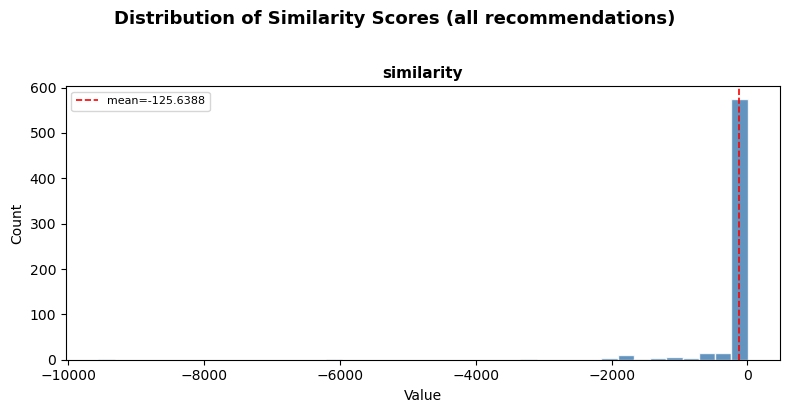

In [9]:
# ---------- Distribution of similarity scores ----------
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vals = recs_df['similarity'].dropna()
ax.hist(vals, bins=40, edgecolor='white', alpha=0.85, color='steelblue')
ax.axvline(vals.mean(), color='red', ls='--', lw=1.2, label=f'mean={vals.mean():.4f}')
ax.set_title('similarity', fontsize=11, fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

fig.suptitle('Distribution of Similarity Scores (all recommendations)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Same-Minute Action Redundancy

Since PV data is **minute-wise**, multiple operator actions within the same minute produce **identical PV context** and therefore **identical recommendations**. This inflates apparent performance metrics and hides where the model actually has discriminative ability.

In [10]:
# ---------- Same-minute analysis on ACTUAL actions ----------
actuals_df['minute'] = actuals_df['action_time'].dt.floor('min')
actuals_df['is_same_minute'] = actuals_df.groupby(['episode_id', 'minute'])['action_group'].transform('count') > 1

n_total  = len(actuals_df)
n_same   = actuals_df['is_same_minute'].sum()
n_unique = n_total - n_same

print("=== Same-Minute Redundancy (Actual Operator Actions) ===\n")
print(f"Total actual actions:             {n_total}")
print(f"Actions sharing a minute:         {n_same}  ({100*n_same/n_total:.1f}%)")
print(f"Actions with unique minute:       {n_unique}  ({100*n_unique/n_total:.1f}%)")
print()

# For same-minute groups, check if the recommendations (from their action_group) are identical
same_min_groups = actuals_df[actuals_df['is_same_minute']].groupby(['episode_id', 'minute'])

# For each same-minute group of actuals, get rank-1 recs and check if identical
identical_count = 0
for (ep, minute), grp in same_min_groups:
    # Get rank-1 recs for these action_groups
    action_groups = grp['action_group'].values
    group_recs = recs_df[(recs_df['episode_id'] == ep) & (recs_df['action_group'].isin(action_groups)) & (recs_df['rank'] == 1)]
    unique_recs = group_recs[['source', 'direction', 'magnitude']].drop_duplicates()
    if len(unique_recs) == 1:
        identical_count += 1

print(f"Same-minute groups with identical top-1 rec: {identical_count}/{same_min_groups.ngroups} "
      f"({100*identical_count/same_min_groups.ngroups:.0f}%)" if same_min_groups.ngroups > 0 else "No same-minute groups found.")

=== Same-Minute Redundancy (Actual Operator Actions) ===

Total actual actions:             210
Actions sharing a minute:         2  (1.0%)
Actions with unique minute:       208  (99.0%)

Same-minute groups with identical top-1 rec: 1/1 (100%)


In [11]:
# ---------- Per-episode same-minute breakdown ----------
episode_stats = []
for ep_id, ep_df in actuals_df.groupby('episode_id'):
    n_actions = len(ep_df)
    n_minutes = ep_df['minute'].nunique()
    n_same_min = ep_df['is_same_minute'].sum()
    episode_stats.append({
        'episode_id': ep_id,
        'total_actions': n_actions,
        'unique_minutes': n_minutes,
        'same_minute_actions': n_same_min,
        'same_minute_pct': round(100 * n_same_min / n_actions, 1) if n_actions else 0
    })

ep_stats_df = pd.DataFrame(episode_stats).sort_values('same_minute_pct', ascending=False)

print("=== Per-Episode Same-Minute Redundancy (Actual Actions) ===\n")
print(ep_stats_df.to_string(index=False))
print(f"\nEpisodes with >50% same-minute actions: {(ep_stats_df['same_minute_pct'] > 50).sum()}/{len(ep_stats_df)}")

=== Per-Episode Same-Minute Redundancy (Actual Actions) ===

 episode_id  total_actions  unique_minutes  same_minute_actions  same_minute_pct
        567             24              23                    2              8.3
        521              1               1                    0              0.0
        522              1               1                    0              0.0
        528              8               8                    0              0.0
        527              4               4                    0              0.0
        530              4               4                    0              0.0
        531             13              13                    0              0.0
        533              6               6                    0              0.0
        529              8               8                    0              0.0
        542              9               9                    0              0.0
        546              1               1      

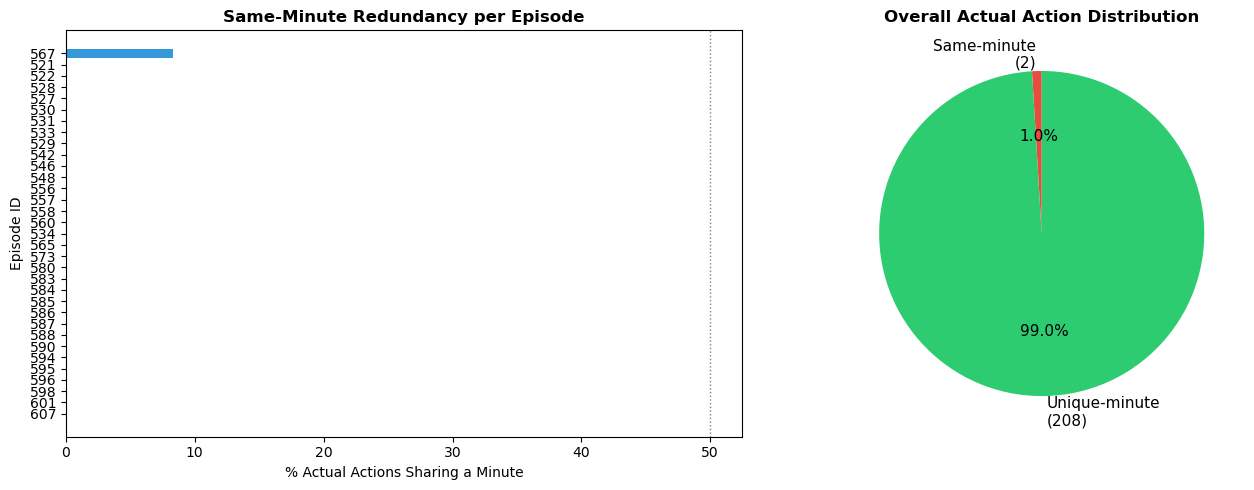

In [12]:
# ---------- Visualize same-minute problem ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: per-episode same-minute %
ax = axes[0]
colors = ['#e74c3c' if p > 50 else '#3498db' for p in ep_stats_df['same_minute_pct']]
ax.barh(ep_stats_df['episode_id'].astype(str), ep_stats_df['same_minute_pct'], color=colors)
ax.set_xlabel('% Actual Actions Sharing a Minute')
ax.set_ylabel('Episode ID')
ax.set_title('Same-Minute Redundancy per Episode', fontweight='bold')
ax.axvline(50, color='gray', ls=':', lw=1)
ax.invert_yaxis()

# Pie: overall split
ax = axes[1]
ax.pie([n_same, n_unique],
       labels=[f'Same-minute\n({n_same})', f'Unique-minute\n({n_unique})'],
       colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%', startangle=90,
       textprops={'fontsize': 11})
ax.set_title('Overall Actual Action Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Accuracy Metrics – All Actions vs. Deduplicated (Unique-Minute)

We compute accuracy two ways:
- **All actions**: every action row evaluated (inflated by same-minute duplicates)
- **Deduplicated**: keep only **one action per episode-minute** (the first), removing redundant copies that share identical PV context

In [13]:
# ---------- Accuracy: build per-action evaluation using the match columns ----------
# Each action_group has 1 actual + 3 recommended rows (rank 1-3).
# Match columns in the Excel: tag_match, direction_match, magnitude_match, type_match

# Get top-1 recommendation per action_group (rank == 1)
top1_recs = recs_df[recs_df['rank'] == 1].copy()

# Merge minute info from actuals
top1_recs = top1_recs.merge(
    actuals_df[['episode_id', 'action_group', 'minute', 'is_same_minute']],
    on=['episode_id', 'action_group'], how='left'
)

# Deduplicate: keep first action per episode-minute
top1_sorted = top1_recs.sort_values(['episode_id', 'minute', 'action_group'])
top1_dedup = top1_sorted.drop_duplicates(subset=['episode_id', 'minute'], keep='first')

print(f"Top-1 recs before dedup: {len(top1_recs)}")
print(f"Top-1 recs after  dedup: {len(top1_dedup)}  (removed {len(top1_recs)-len(top1_dedup)} same-minute duplicates)\n")

def compute_metrics(df, label):
    """Compute match rates using pre-computed match columns."""
    return {
        'subset': label,
        'n_actions': len(df),
        'tag_match': f"{df['tag_match'].mean():.1%}",
        'direction_match': f"{df['direction_match'].mean():.1%}",
        'type_match': f"{df['type_match'].mean():.1%}",
        'magnitude_match': f"{df['magnitude_match'].mean():.1%}",
        'avg_similarity': f"{df['similarity'].mean():.4f}",
    }

metrics = pd.DataFrame([
    compute_metrics(top1_recs, 'All actions (Top 1)'),
    compute_metrics(top1_dedup, 'Deduplicated (Top 1)'),
    compute_metrics(top1_recs[~top1_recs['is_same_minute']], 'Unique-minute only (Top 1)'),
    compute_metrics(top1_recs[top1_recs['is_same_minute']], 'Same-minute only (Top 1)'),
])
print("=== Accuracy Comparison ===\n")
print(metrics.to_string(index=False))

Top-1 recs before dedup: 212
Top-1 recs after  dedup: 209  (removed 3 same-minute duplicates)

=== Accuracy Comparison ===

                    subset  n_actions tag_match direction_match type_match magnitude_match avg_similarity
       All actions (Top 1)        212     86.3%           57.1%      86.8%           65.1%       -72.3522
      Deduplicated (Top 1)        209     86.6%           57.9%      87.1%           64.6%       -73.3847
Unique-minute only (Top 1)        208     87.0%           58.2%      87.5%           64.4%       -73.7355
  Same-minute only (Top 1)          4     50.0%            0.0%      50.0%          100.0%        -0.4202


## 4. Accuracy Across All Ranks (Top-K Analysis)

Each action gets 3 ranked recommendations. Check if the correct tag/direction appears anywhere in top-K (deduplicated by minute).

In [24]:
# ---------- Top-K hit rates (deduplicated by minute) ----------
# Merge minute info into all recs
all_recs = recs_df.merge(
    actuals_df[['episode_id', 'action_group', 'minute']],
    on=['episode_id', 'action_group'], how='left'
)

# Deduplicate: for each (episode, minute), keep only recs from the first action_group
first_ag_per_minute = actuals_df.sort_values('action_group').drop_duplicates(
    subset=['episode_id', 'minute'], keep='first'
)[['episode_id', 'minute', 'action_group']]

recs_dedup = all_recs.merge(first_ag_per_minute, on=['episode_id', 'minute', 'action_group'])

print(f"Deduplicated rec rows: {len(recs_dedup)}  (unique minutes x recs)")
print()

topk_metrics = []
for k in [1, 2, 3]:
    subset = recs_dedup[recs_dedup['rank'] <= k].copy()
    grouped = subset.groupby(['episode_id', 'minute'])

    # Base hit metrics
    tag_hit = grouped['tag_match'].max()       
    dir_hit = grouped['direction_match'].max()
    both_hit = grouped.apply(
        lambda g: ((g['tag_match'] == 1.0) & (g['direction_match'] == 1.0)).any()
    )

    # Tag+Direction+Magnitude (tolerance-based)
    subset['tag_dir_ok'] = (subset['tag_match'] == 1.0) & (subset['direction_match'] == 1.0)
    subset['abs_mag_err'] = (subset['magnitude'] - subset['actual_magnitude']).abs()
    subset['tdm_hit_tol_1'] = subset['tag_dir_ok'] & (subset['abs_mag_err'] <= 1.0)
    subset['tdm_hit_tol_2'] = subset['tag_dir_ok'] & (subset['abs_mag_err'] <= 2.0)

    tdm_tol1_hit = subset.groupby(['episode_id', 'minute'])['tdm_hit_tol_1'].max()
    tdm_tol2_hit = subset.groupby(['episode_id', 'minute'])['tdm_hit_tol_2'].max()

    topk_metrics.append({
        'top_k': k,
        'n_unique_actions': len(grouped),
        'tag_hit_rate': f"{(tag_hit == 1.0).mean():.1%}",
        'direction_hit_rate': f"{(dir_hit == 1.0).mean():.1%}",
        'tag+direction_hit_rate': f"{both_hit.mean():.1%}",
        'tag+dir+mag(±1)_hit_rate': f"{tdm_tol1_hit.mean():.1%}",
        'tag+dir+mag(±2)_hit_rate': f"{tdm_tol2_hit.mean():.1%}",
    })

topk_df = pd.DataFrame(topk_metrics)
print("=== Top-K Hit Rates (deduplicated, one per episode-minute) ===\n")
print(topk_df.to_string(index=False))

Deduplicated rec rows: 630  (unique minutes x recs)

=== Top-K Hit Rates (deduplicated, one per episode-minute) ===

 top_k  n_unique_actions tag_hit_rate direction_hit_rate tag+direction_hit_rate tag+dir+mag(±1)_hit_rate tag+dir+mag(±2)_hit_rate
     1               209        86.6%              57.9%                  51.2%                    36.8%                    43.1%
     2               209        90.9%              71.3%                  59.8%                    44.0%                    52.6%
     3               209        93.8%              81.3%                  65.6%                    50.2%                    58.4%


## 5. Per-Episode Accuracy (Deduplicated)

How does accuracy vary across episodes? Some episodes may be consistently well-predicted while others are poor.

In [15]:
# ---------- Per-episode accuracy (top-1, deduplicated) ----------
ep_accuracy = []
for ep_id, grp in top1_dedup.groupby('episode_id'):
    n = len(grp)
    tag_m = grp['tag_match'].mean()
    dir_m = grp['direction_match'].mean()
    both_m = ((grp['tag_match'] == 1.0) & (grp['direction_match'] == 1.0)).mean()
    mag_m = grp['magnitude_match'].mean()
    type_m = grp['type_match'].mean()
    avg_sim = grp['similarity'].mean()
    
    ep_accuracy.append({
        'episode_id': ep_id, 'n_unique_actions': n,
        'tag_match%': round(100*tag_m, 1), 'dir_match%': round(100*dir_m, 1),
        'tag+dir_match%': round(100*both_m, 1), 'type_match%': round(100*type_m, 1),
        'mag_match%': round(100*mag_m, 1), 'avg_similarity': round(avg_sim, 4)
    })

ep_acc_df = pd.DataFrame(ep_accuracy).sort_values('tag+dir_match%', ascending=False)

print("=== Per-Episode Accuracy (Top 1, Deduplicated) ===\n")
print(ep_acc_df.to_string(index=False))

=== Per-Episode Accuracy (Top 1, Deduplicated) ===

 episode_id  n_unique_actions  tag_match%  dir_match%  tag+dir_match%  type_match%  mag_match%  avg_similarity
        521                 1       100.0       100.0           100.0          0.0       100.0          0.6079
        522                 1       100.0       100.0           100.0          0.0       100.0          0.6362
        546                 1       100.0       100.0           100.0        100.0       100.0          0.9312
        548                 4       100.0       100.0           100.0        100.0       100.0          0.5643
        573                 6       100.0       100.0           100.0        100.0       100.0          0.9496
        588                 1       100.0       100.0           100.0        100.0       100.0          0.5812
        601                 5       100.0       100.0           100.0        100.0        60.0          0.6825
        584                 5       100.0       100.0       

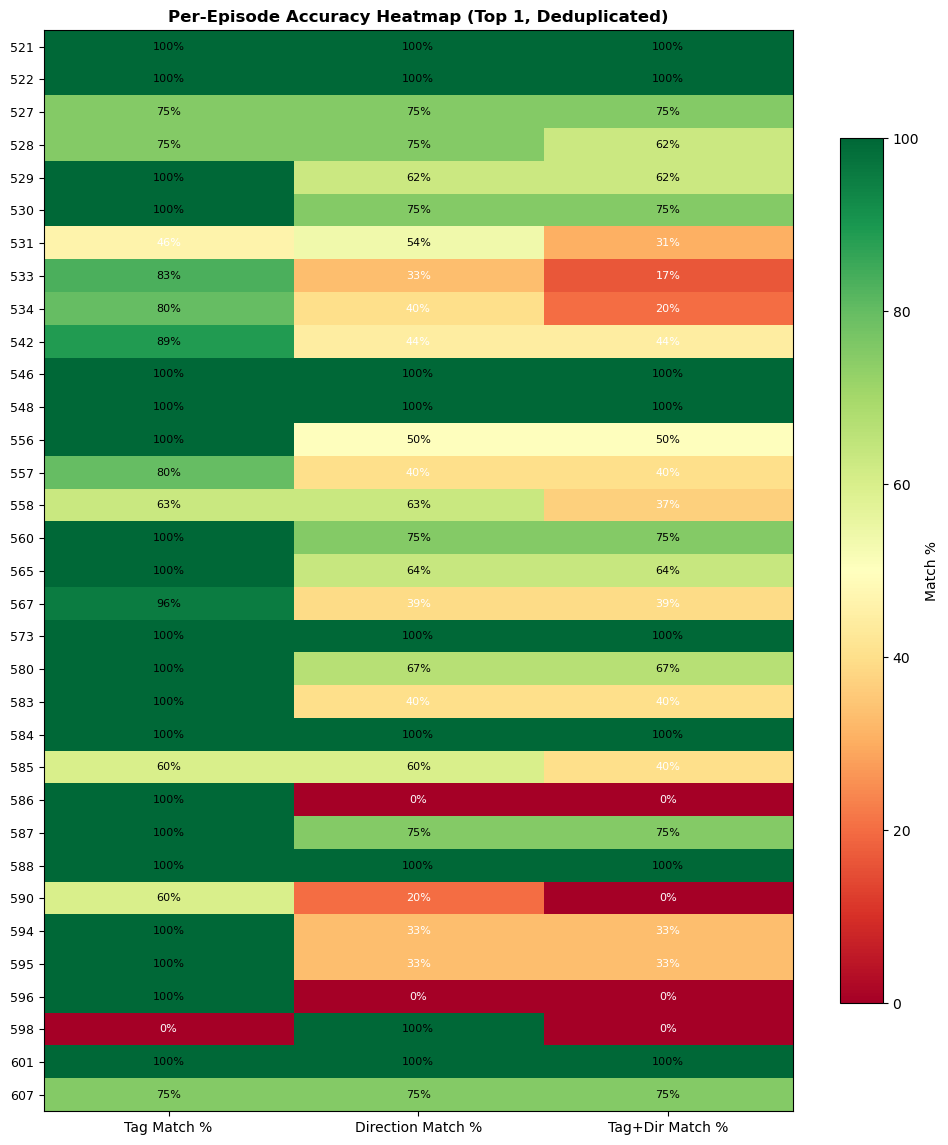

In [16]:
# ---------- Per-episode accuracy heatmap ----------
fig, ax = plt.subplots(figsize=(10, max(6, len(ep_acc_df)*0.35)))

plot_data = ep_acc_df.set_index('episode_id')[['tag_match%', 'dir_match%', 'tag+dir_match%']].copy()
plot_data = plot_data.sort_index()

im = ax.imshow(plot_data.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)

ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data.index, fontsize=9)
ax.set_xticks(range(3))
ax.set_xticklabels(['Tag Match %', 'Direction Match %', 'Tag+Dir Match %'], fontsize=10)

for i in range(len(plot_data)):
    for j in range(3):
        val = plot_data.values[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=8,
                color='white' if val < 50 else 'black')

ax.set_title('Per-Episode Accuracy Heatmap (Top 1, Deduplicated)', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='Match %', shrink=0.8)
plt.tight_layout()
plt.show()

## 6. Matched-Episode Concentration

Which training episodes are being matched most frequently? High concentration on a few episodes may indicate overfitting or that only a few contexts are sufficiently similar.

=== Most Frequently Matched Training Episodes (Top 1, Deduped) ===

matched_episode_id
468.0    34
564.0    29
602.0    15
597.0    13
547.0    12
604.0    12
574.0     9
609.0     8
483.0     7
577.0     6
447.0     6
444.0     6
390.0     5
119.0     5
271.0     3

Total unique matched episodes: 39
Top-3 episodes cover: 78/209 (37.3%) of all matches


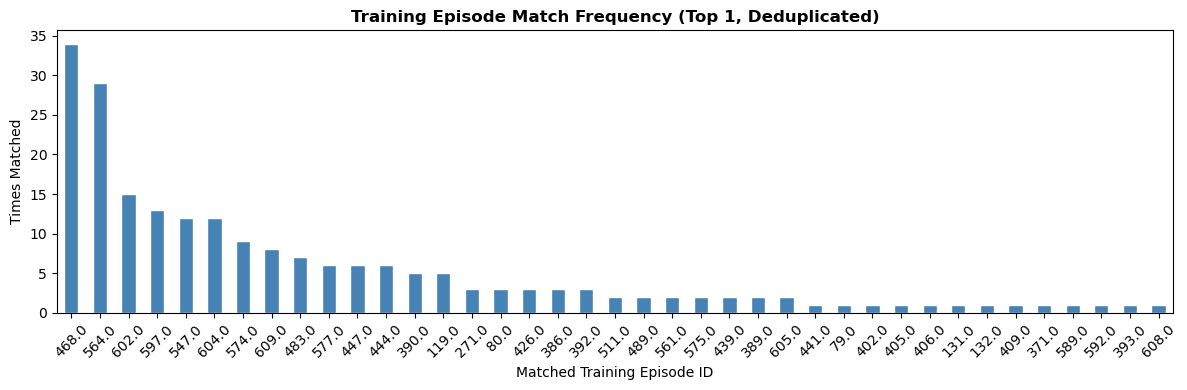

In [17]:
# ---------- Which training episodes are being matched? ----------
match_counts = top1_dedup['matched_episode_id'].value_counts()

print("=== Most Frequently Matched Training Episodes (Top 1, Deduped) ===\n")
print(match_counts.head(15).to_string())
print(f"\nTotal unique matched episodes: {match_counts.shape[0]}")
print(f"Top-3 episodes cover: {match_counts.head(3).sum()}/{match_counts.sum()} "
      f"({100*match_counts.head(3).sum()/match_counts.sum():.1f}%) of all matches")

fig, ax = plt.subplots(figsize=(12, 4))
match_counts.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Matched Training Episode ID')
ax.set_ylabel('Times Matched')
ax.set_title('Training Episode Match Frequency (Top 1, Deduplicated)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 7. Tag & Direction Confusion Analysis

Which tags are recommended vs what was actually operated? And where do direction errors occur?

In [18]:
# ---------- Tag confusion matrix ----------
d = top1_dedup.copy()

# Tag confusion: actual_source vs recommended source (actual_source was merged in Cell 2)
tag_pairs = list(zip(d['actual_source'], d['source']))
all_tags = sorted(set(d['actual_source'].unique()) | set(d['source'].unique()))
tag_confusion = pd.DataFrame(0, index=all_tags, columns=all_tags)
for actual, rec in tag_pairs:
    tag_confusion.loc[actual, rec] += 1

print("=== Tag Confusion Matrix (Top 1, Deduplicated) ===")
print("  Rows = Actual tag, Columns = Recommended tag\n")
print(tag_confusion.to_string())
print()

# Direction confusion
dir_map = {0: 'Decrease', 1: 'Increase'}
d['actual_dir_label'] = d['actual_direction'].map(dir_map)
d['rec_dir_label'] = d['direction'].map(dir_map)

dir_confusion = pd.crosstab(d['actual_dir_label'], d['rec_dir_label'],
                            rownames=['Actual'], colnames=['Recommended'])
print("=== Direction Confusion Matrix ===\n")
print(dir_confusion.to_string())
print()

# Where does tag mismatch happen?
mismatches = d[d['tag_match'] != 1.0]
print(f"Tag mismatches: {len(mismatches)}/{len(d)} ({100*len(mismatches)/len(d):.1f}%)")
if len(mismatches) > 0:
    print("\nMismatch breakdown:")
    for _, row in mismatches.iterrows():
        print(f"  Ep {row['episode_id']}: actual={row['actual_source']} rec={row['source']}  "
              f"sim={row['similarity']:.4f}")

=== Tag Confusion Matrix (Top 1, Deduplicated) ===
  Rows = Actual tag, Columns = Recommended tag

            03LIC_1016  03LIC_1071  03PIC_1013
03LIC_1016           0           0           0
03LIC_1071           7          57           9
03PIC_1013           1          11         124

=== Direction Confusion Matrix ===

Recommended  Decrease  Increase
Actual                         
Decrease           69        54
Increase           34        52

Tag mismatches: 28/209 (13.4%)

Mismatch breakdown:
  Ep 527: actual=03LIC_1071 rec=03LIC_1016  sim=0.4339
  Ep 528: actual=03LIC_1071 rec=03PIC_1013  sim=0.4286
  Ep 528: actual=03LIC_1071 rec=03LIC_1016  sim=0.5026
  Ep 531: actual=03LIC_1071 rec=03LIC_1016  sim=0.5746
  Ep 531: actual=03LIC_1071 rec=03LIC_1016  sim=0.5147
  Ep 531: actual=03LIC_1071 rec=03LIC_1016  sim=0.3841
  Ep 531: actual=03LIC_1071 rec=03LIC_1016  sim=0.3570
  Ep 531: actual=03LIC_1071 rec=03PIC_1013  sim=0.3272
  Ep 531: actual=03LIC_1071 rec=03PIC_1013  sim=0.3382


## 8. Magnitude Analysis

Even when tag and direction are correct, how close is the recommended magnitude to the actual?

=== Magnitude Analysis (where tag matches, N=181) ===

Mean absolute error:   2.99
Median absolute error: 2.00
Max absolute error:    33.08



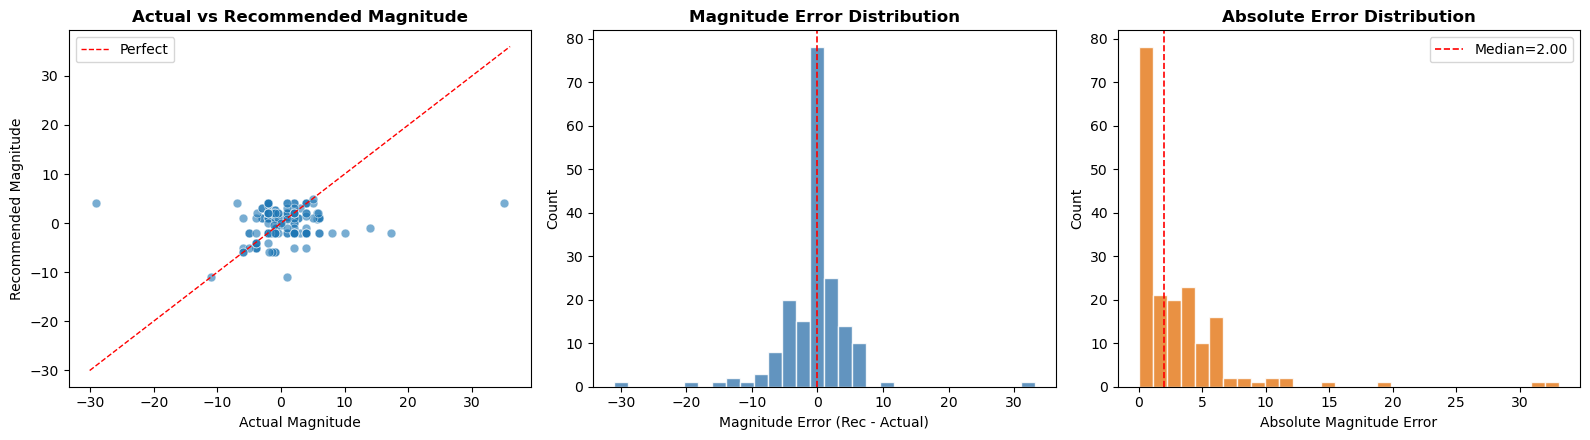

In [19]:
# ---------- Magnitude comparison (where tag matches) ----------
correct_tag = top1_dedup[top1_dedup['tag_match'] == 1.0].copy()

# actual_magnitude was already merged into recs_df in Cell 2
correct_tag['mag_error'] = correct_tag['magnitude'] - correct_tag['actual_magnitude']
correct_tag['abs_mag_error'] = correct_tag['mag_error'].abs()

print(f"=== Magnitude Analysis (where tag matches, N={len(correct_tag)}) ===\n")
print(f"Mean absolute error:   {correct_tag['abs_mag_error'].mean():.2f}")
print(f"Median absolute error: {correct_tag['abs_mag_error'].median():.2f}")
print(f"Max absolute error:    {correct_tag['abs_mag_error'].max():.2f}")
print()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.scatter(correct_tag['actual_magnitude'], correct_tag['magnitude'],
           alpha=0.6, s=40, edgecolors='white', linewidths=0.5)
lims = [min(correct_tag['actual_magnitude'].min(), correct_tag['magnitude'].min()) - 1,
        max(correct_tag['actual_magnitude'].max(), correct_tag['magnitude'].max()) + 1]
ax.plot(lims, lims, 'r--', lw=1, label='Perfect')
ax.set_xlabel('Actual Magnitude')
ax.set_ylabel('Recommended Magnitude')
ax.set_title('Actual vs Recommended Magnitude', fontweight='bold')
ax.legend()

ax = axes[1]
ax.hist(correct_tag['mag_error'], bins=30, edgecolor='white', alpha=0.85, color='steelblue')
ax.axvline(0, color='red', ls='--', lw=1.2)
ax.set_xlabel('Magnitude Error (Rec - Actual)')
ax.set_ylabel('Count')
ax.set_title('Magnitude Error Distribution', fontweight='bold')

ax = axes[2]
ax.hist(correct_tag['abs_mag_error'], bins=30, edgecolor='white', alpha=0.85, color='#e67e22')
ax.axvline(correct_tag['abs_mag_error'].median(), color='red', ls='--', lw=1.2,
           label=f'Median={correct_tag["abs_mag_error"].median():.2f}')
ax.set_xlabel('Absolute Magnitude Error')
ax.set_ylabel('Count')
ax.set_title('Absolute Error Distribution', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

## 9. Similarity Score vs Accuracy Relationship

Is higher similarity score actually predictive of a correct recommendation?

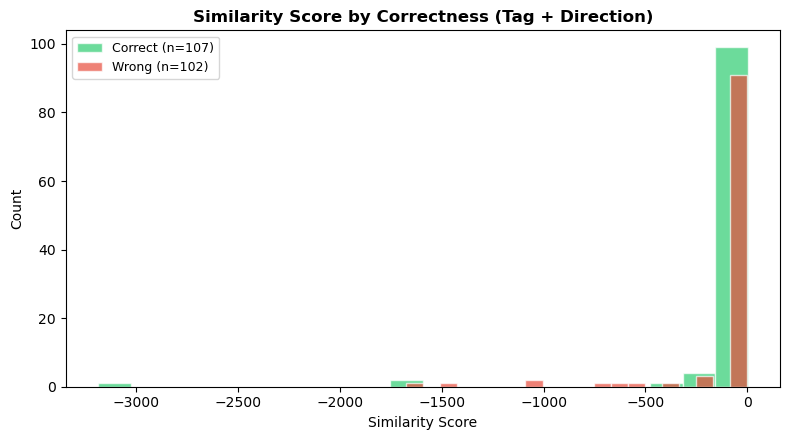

Mean similarity for correct vs wrong recommendations:

  similarity              Correct=-70.0171  Wrong=-76.9175  delta=+6.9004


In [20]:
# ---------- Similarity vs correctness ----------
d = top1_dedup.copy()
d['both_correct'] = ((d['tag_match'] == 1.0) & (d['direction_match'] == 1.0)).astype(int)

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))

correct = d[d['both_correct'] == 1]['similarity']
wrong   = d[d['both_correct'] == 0]['similarity']

ax.hist(correct, bins=20, alpha=0.7, label=f'Correct (n={len(correct)})', color='#2ecc71', edgecolor='white')
ax.hist(wrong, bins=20, alpha=0.7, label=f'Wrong (n={len(wrong)})', color='#e74c3c', edgecolor='white')
ax.set_xlabel('Similarity Score')
ax.set_ylabel('Count')
ax.set_title('Similarity Score by Correctness (Tag + Direction)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Mean similarity for correct vs wrong recommendations:\n")
c_mean = d[d['both_correct']==1]['similarity'].mean()
w_mean = d[d['both_correct']==0]['similarity'].mean()
print(f"  {'similarity':22s}  Correct={c_mean:.4f}  Wrong={w_mean:.4f}  delta={c_mean-w_mean:+.4f}")

## 10. Same-Minute Deep Dive: What the Operator Actually Did

For actions in the same minute, the operator often took **different actions** on different tags (or same tag, different direction/magnitude) — but we recommend the **same thing** for all of them. Let's look at the actual operator behaviour in these cases.

In [21]:
# ---------- Same-minute: what did the operator really do? ----------
same_min_actuals = actuals_df[actuals_df['is_same_minute']].copy()
same_min_groups = same_min_actuals.groupby(['episode_id', 'minute'])

print(f"=== Same-Minute Action Groups: {same_min_groups.ngroups} groups, {len(same_min_actuals)} total actions ===\n")

group_diversity = []
for (ep, minute), grp in same_min_groups:
    n_actions = len(grp)
    unique_actual_dirs = grp[['source', 'direction']].drop_duplicates().shape[0]
    
    group_diversity.append({
        'episode_id': ep, 'minute': minute,
        'n_actions_in_minute': n_actions,
        'unique_actual_tag_dir': unique_actual_dirs,
        'tags_operated': ', '.join(grp['source'].unique()),
    })

gd = pd.DataFrame(group_diversity)

print("Diversity of actual actions within same-minute groups:\n")
print(f"  Groups where operator did >1 distinct (tag,dir) action:  "
      f"{(gd['unique_actual_tag_dir']>1).sum()}/{len(gd)} "
      f"({100*(gd['unique_actual_tag_dir']>1).sum()/len(gd):.1f}%)")
print()

# Show examples
diverse = gd[gd['unique_actual_tag_dir'] > 1].head(8)
if len(diverse) > 0:
    print("Sample same-minute groups with diverse actual actions:\n")
    print(diverse[['episode_id','minute','n_actions_in_minute','unique_actual_tag_dir','tags_operated']].to_string(index=False))
else:
    print("All same-minute groups have the same (tag, direction) — operator does repeated small steps on same tag.")

=== Same-Minute Action Groups: 1 groups, 2 total actions ===

Diversity of actual actions within same-minute groups:

  Groups where operator did >1 distinct (tag,dir) action:  1/1 (100.0%)

Sample same-minute groups with diverse actual actions:

 episode_id              minute  n_actions_in_minute  unique_actual_tag_dir          tags_operated
        567 2025-05-09 11:52:00                    2                      2 03LIC_1071, 03PIC_1013


## 11. Action Type Match Analysis

Check how well the recommended action type (OP/SP) matches the actual operator action type.

In [22]:
# ---------- Action type match ----------
d = top1_dedup.copy()

# type_match column from Excel
at_match = d['type_match'].mean()
print(f"=== Action Type Match (Top 1, Deduplicated) ===\n")
print(f"Action type match rate: {at_match:.1%}")
print()

# Crosstab of rec action_type vs actual_action_type (actual_action_type merged in Cell 2)
ct = pd.crosstab(d['actual_action_type'], d['action_type'],
                 rownames=['Actual Type'], colnames=['Recommended Type'], margins=True)
print(ct.to_string())
print()

# Combined match: tag + direction + action_type
d['all_match'] = ((d['tag_match'] == 1.0) & 
                  (d['direction_match'] == 1.0) & 
                  (d['type_match'] == 1.0))
print(f"Tag + Direction + Action Type match: {d['all_match'].mean():.1%}")
print()

# Full match including magnitude
d['full_match'] = d['all_match'] & (d['magnitude_match'] == 1.0)
print(f"Full match (tag + dir + type + magnitude): {d['full_match'].mean():.1%}")

=== Action Type Match (Top 1, Deduplicated) ===

Action type match rate: 87.1%

Recommended Type   OP  SP  All
Actual Type                   
OP                180  18  198
SP                  9   2   11
All               189  20  209

Tag + Direction + Action Type match: 47.8%

Full match (tag + dir + type + magnitude): 42.6%


## 12. Summary & Key Findings

In [23]:
# ---------- Final summary ----------
print("=" * 70)
print("  RESULTS ANALYSIS SUMMARY")
print("=" * 70)
print()

n_episodes = top1_dedup['episode_id'].nunique()
n_all      = len(top1_recs)
n_dedup    = len(top1_dedup)

tag_m  = top1_dedup['tag_match'].mean()
dir_m  = top1_dedup['direction_match'].mean()
both_m = ((top1_dedup['tag_match'] == 1.0) & (top1_dedup['direction_match'] == 1.0)).mean()
mag_m  = top1_dedup['magnitude_match'].mean()
type_m = top1_dedup['type_match'].mean()

print(f"  Data source: operator_action_recommendations_by_episode.xlsx")
print(f"  Episodes tested:              {n_episodes}")
print(f"  Total actual actions:         {n_all}")
print(f"  Unique-minute actions:        {n_dedup} ({100*n_dedup/n_all:.1f}%)")
print(f"  Same-minute duplicates:       {n_all-n_dedup} ({100*(n_all-n_dedup)/n_all:.1f}%)")
print()
print(f"  --- Top-1 Accuracy (Deduplicated) ---")
print(f"  Tag match:                    {tag_m:.1%}")
print(f"  Direction match:              {dir_m:.1%}")
print(f"  Tag + Direction match:        {both_m:.1%}")
print(f"  Type match:                   {type_m:.1%}")
print(f"  Magnitude match:              {mag_m:.1%}")
print()
print(f"  --- Similarity Scores ---")
print(f"  Overall similarity (mean):    {top1_dedup['similarity'].mean():.4f}")
print()
print("  --- Key Observations ---")
print(f"  1. {100*(n_all-n_dedup)/n_all:.0f}% of actual actions share a minute → identical recs (redundant)")
print(f"  2. Only {match_counts.shape[0]} unique training episodes matched")
print(f"  3. Top-3 matched episodes cover {100*match_counts.head(3).sum()/match_counts.sum():.0f}% of all matches")
print()
print("=" * 70)

  RESULTS ANALYSIS SUMMARY

  Data source: operator_action_recommendations_by_episode.xlsx
  Episodes tested:              33
  Total actual actions:         212
  Unique-minute actions:        209 (98.6%)
  Same-minute duplicates:       3 (1.4%)

  --- Top-1 Accuracy (Deduplicated) ---
  Tag match:                    86.6%
  Direction match:              57.9%
  Tag + Direction match:        51.2%
  Type match:                   87.1%
  Magnitude match:              64.6%

  --- Similarity Scores ---
  Overall similarity (mean):    -73.3847

  --- Key Observations ---
  1. 1% of actual actions share a minute → identical recs (redundant)
  2. Only 39 unique training episodes matched
  3. Top-3 matched episodes cover 37% of all matches

